___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Q Learning Exercise 

**We'll be reviewing and testing your skills with Q-Learning on a continuous space! Please feel free to reference the lecture notebooks you are definitely not expected to be able to fill out all this code from memory, just the ability to understand the core concepts and apply it to a different situation.**

--------------------

## Complete the tasks in bold below.

In this exercise we take a look at the MountainCar-v0 (https://gym.openai.com/envs/MountainCar-v0/) game again. That is the game from our original discussion of OpenAi gym environments for which we created an agent manually.
Remember, that the goal is to reach the top of the mountain within some time limit

-----

**TASK: Import any relevant libraries you think you might need.** <br />


In [1]:
%matplotlib notebook
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

**TASK: Create the gym mountain car environment** <br />


In [2]:
env = gym.make('MountainCar-v0')

**TASK: Write a function to create a numpy array holding the bins for the observations of the car (position and velocity).** <br />
Feel free to explore different bins per observation spacings.
The function should take one argument which acts as the bins per observation <br />
Hint: You can find the observations here: https://github.com/openai/gym/blob/master/gym/envs/classic_control/mountain_car.py
<br /> Hint: You will probably need around 25 bins for good results, but feel free to use less to reduce training time. <br />


In [3]:
def create_bins(num_bins_per_observation):
    car_position = np.linspace(-1.2, 0.6, num_bins_per_observation)
    car_velocity = np.linspace(-0.07, 0.07, num_bins_per_observation)
    bins = np.array([car_position, car_velocity])
    return bins

**TASK: Here you should write the code which creates the bins and defines the NUM_BINS attribute**

In [4]:
NUM_BINS = 40
BINS = create_bins(NUM_BINS)

**TASK: Create a function that will take in observations from the environment and the bins array and return the discretized version of the observation.**

Now we need the code to discretize the observations. We can use the same code as used in the last notebook

In [5]:
def discretize_observation(observations, bins):
    binned_observations = []

    for i, observation in enumerate(observations):
        binned_observations.append(np.digitize(observation, bins[i]))
    
    return tuple(binned_observations)

**Let's check to make sure your previous two function calls work with a quick task! Otherwise it may be hard to debug later on.**

**TASK: Confirm that your *create_bins()* function works with *discretize_observation() by running the following cell***

In [6]:
test_bins = create_bins(5)
np.testing.assert_almost_equal(test_bins[0], [-1.2 , -0.75, -0.3 ,  0.15,  0.6])
np.testing.assert_almost_equal(test_bins[1], [-0.07 , -0.035,  0.   ,  0.035,  0.07 ])

test_observation = np.array([-0.9, 0.03])
discretized_test_bins = discretize_observation(test_observation, test_bins)
assert discretized_test_bins == (1, 3)

**TASK: Create the Q-Table** <br />
Remember the shape that the Q-Table needs to have.

In [7]:
q_shape = (NUM_BINS, NUM_BINS, (env.action_space.n))
q_shape

(40, 40, np.int64(3))

In [8]:
q_table = np.zeros(q_shape)

**TASK: Fill out the Epislon Greedy Action Selection function:**

In [9]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    if np.random.random() > epsilon:
        action = np.argmax(q_table[discrete_state])
    else:
        action = np.random.randint(0, env.action_space.n)
        
    return action

**TASK: Fill out the function to compute the next Q value.**

In [10]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    
    return old_q_value + ALPHA*(reward + GAMMA*next_optimal_q_value - old_q_value)

**TASK: Create a function to reduce epsilon, feel free to choose any reduction method you want. We'll use a reduction with BURN_IN and EPSILON_END limits in the solution. We'll also show a way to reduce epsilon based on the number of epochs. Feel free to experiment here.**

In [11]:
def reduce_epsilon(epsilon, epoch):
    if BURN_IN <= epoch <= EPSILON_END:
        epsilon -= EPSILON_REDUCE
    return epsilon

**TASK: Define your hyperparameters. Note, we'll show our solution hyperparameters here, but depending on your *reduce_epsilon* function, your epsilon hyperparameters may be different.**

Here are the solution initial hyperparameters, your will probably be different!

In [18]:
EPOCHS = 30000
BURN_IN = 100
epsilon = 1

EPSILON_END= 10000
EPSILON_REDUCE = 0.0001 

ALPHA = 0.1
GAMMA = 0.9


**TASK: Create the training loop for the reinforcement learning agent and run the loop. We've gone ahead and created the basic structure of the loopwith some comments. We also pre-filled the visualization portion.** <br />
Note: Use the lecture notebook as a guide and reference

In [19]:
from IPython.display import clear_output

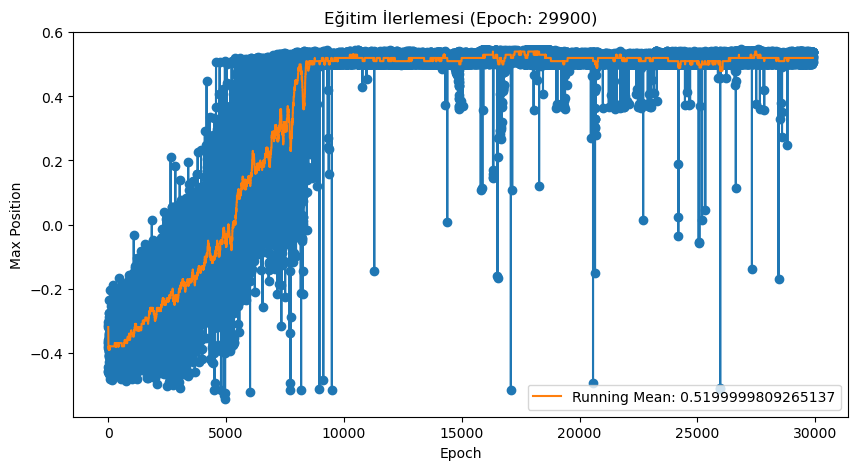

In [20]:
%matplotlib inline
max_position_log = []
mean_positions_log = []
epochs = []

log_interval = 100


for epoch in range(EPOCHS):
    state, info = env.reset()
    discretized_state = discretize_observation(state, BINS)
    truncated = terminated = False


    
    max_position = -np.inf  
    epochs.append(epoch)
    
    while not (terminated or truncated):

        action = epsilon_greedy_action_selection(epsilon, q_table, discretized_state)

        next_state, reward, terminated, truncated, info = env.step(action)
        position, velocity = next_state
        next_state_discretized = discretize_observation(next_state, BINS)

        old_q_value = q_table[discretized_state + (action,)]
        next_optimal_q_value = np.max(q_table[next_state_discretized])

        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)
        q_table[discretized_state + (action, )] = next_q

        discretized_state = next_state_discretized
        
        
        if position > max_position:  
            max_position = position

    epsilon = reduce_epsilon(epsilon, epoch)


    max_position_log.append(max_position)
    running_mean = round(np.mean(max_position_log[-100:]), 2)
    mean_positions_log.append(running_mean)
    
    if epoch % log_interval == 0:
        clear_output(wait=True)
        
        fig = plt.figure(figsize=(10, 5))
        plt.scatter(epochs, max_position_log)
        plt.plot(epochs, max_position_log)
        plt.plot(epochs, mean_positions_log, label=f"Running Mean: {running_mean}")
        plt.xlabel("Epoch")
        plt.ylabel("Max Position")
        plt.title(f"Eğitim İlerlemesi (Epoch: {epoch})")
        plt.legend()
        
        plt.show()


**TASK: Use your Q-Table to test your agent and render its performance.**

In [21]:
env_hum = gym.make('MountainCar-v0', render_mode = 'human')

In [22]:
observation, info = env_hum.reset()
for step in range(2000):
    env_hum.render()

    discrete_state = discretize_observation(observation, BINS)
    action = np.argmax(q_table[discrete_state])
    observation, reward, terminated, truncated, info = env_hum.step(action)

    if terminated or truncated:
        print('done')
        break

done
